# Cuisine Discovery - Unsupervised Learning (RecipeNLG)

This notebook discovers hidden cuisine styles from recipe titles and ingredients using LDA topic modeling and KMeans Clustering.

In [35]:
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

In [18]:
data_path = "RecipeNLG_dataset.csv"

# Load only required columns
raw_df = pd.read_csv(data_path, usecols=["title", "ingredients"], low_memory=False)

# Drop missing values early
raw_df = raw_df.dropna(subset=["title", "ingredients"]).reset_index(drop=True)

# Convert ingredients to text if stored as a list-like string

def ingredients_to_text(val: str) -> str:
    if isinstance(val, str) and val.strip().startswith("["):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return " ".join([str(x) for x in parsed])
        except (ValueError, SyntaxError):
            pass
    return str(val)

raw_df["ingredients"] = raw_df["ingredients"].apply(ingredients_to_text)

# Combine title + ingredients
raw_df["text"] = raw_df["title"].astype(str) + " " + raw_df["ingredients"].astype(str)

# Custom stopwords
cooking_stopwords = {
    "salt", "water", "oil", "sugar", "butter", "flour",
    "cup", "cups", "tsp", "tbsp", "teaspoon", "tablespoon",
    "teaspoons", "tablespoons", "oz", "ounce", "ounces", "lb", "lbs",
    "pkg", "package", "can", "cans", "soda", "mix", "instant"
}
stopwords = set(ENGLISH_STOP_WORDS).union(cooking_stopwords)

# Basic text preprocessing
punct_num_regex = re.compile(r"[^a-z\s]")

def preprocess_text(text: str) -> str:
    text = text.lower()
    text = punct_num_regex.sub(" ", text)
    tokens = [t for t in text.split() if t not in stopwords]
    return " ".join(tokens)

raw_df["text_clean"] = raw_df["text"].astype(str).apply(preprocess_text)

# Final clean dataframe
df = raw_df.dropna(subset=["text_clean"]).reset_index(drop=True)

print(f"Rows after cleaning: {len(df):,}")
print(df[["title", "ingredients", "text_clean"]].head())

Rows after cleaning: 2,231,141
                   title                                        ingredients  \
0    No-Bake Nut Cookies  1 c. firmly packed brown sugar 1/2 c. evaporat...   
1  Jewell Ball'S Chicken  1 small jar chipped beef, cut up 4 boned chick...   
2            Creamy Corn  2 (16 oz.) pkg. frozen corn 1 (8 oz.) pkg. cre...   
3          Chicken Funny  1 large whole chicken 2 (10 1/2 oz.) cans chic...   
4   Reeses Cups(Candy)    1 c. peanut butter 3/4 c. graham cracker crumb...   

                                          text_clean  
0  bake nut cookies c firmly packed brown c evapo...  
1  jewell ball s chicken small jar chipped beef c...  
2  creamy corn frozen corn cream cheese cubed c c...  
3  chicken funny large chicken chicken gravy crea...  
4  reeses candy c peanut c graham cracker crumbs ...  


In [19]:
# PART A: LDA - Topic Modeling

count_vectorizer = CountVectorizer(
    max_df=0.85,
    min_df=5,
    stop_words="english",
    max_features=5000
)

dtm = count_vectorizer.fit_transform(df["text_clean"])

print(f"DTM shape: {dtm.shape}")

DTM shape: (2231141, 5000)


In [20]:
# STEP A2: Train LDA and choose number of topics [OPTIMIZED]
# Optimization: Sample data, reduce topic candidates, use fast LDA parameters

# Sample dataset to speed up training (if dataset is large)
sample_size_lda = 50000 if len(df) > 50000 else len(df)
df_lda_sample = df.sample(n=sample_size_lda, random_state=RANDOM_STATE)

# Re-vectorize with smaller dataset
count_vectorizer_opt = CountVectorizer(
    max_df=0.85,
    min_df=5,
    stop_words="english",
    max_features=5000
)
dtm_opt = count_vectorizer_opt.fit_transform(df_lda_sample["text_clean"])

# Test fewer topic candidates (3 instead of 6)
n_topics_range = [8, 10, 12]  # Reduced from range(5, 11)

perplexity_scores = {}
lda_models = {}

print("Training LDA models (optimized)...")
for k in n_topics_range:
    print(f"  Training LDA with k={k}...")
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=RANDOM_STATE,
        max_iter=8,  # Reduced iterations for speed
        learning_method="online",
        learning_decay=0.5,
        n_jobs=-1,
        batch_size=256,
        verbose=0
    )
    lda.fit(dtm_opt)
    lda_models[k] = lda
    perplexity_scores[k] = lda.perplexity(dtm_opt)

print("\nPerplexity by topic count:")
print(perplexity_scores)

# Select best k by perplexity (fastest method)
optimal_k = min(perplexity_scores, key=perplexity_scores.get)

print(f"Optimal topics: {optimal_k} (by perplexity)")

# Optionally retrain on full dataset (can be slow)
RETRAIN_FULL = False

if RETRAIN_FULL:
    print(f"\nRetraining LDA on full dataset with k={optimal_k}...")
    lda_model = LatentDirichletAllocation(
        n_components=optimal_k,
        random_state=RANDOM_STATE,
        max_iter=10,
        learning_method="online",
        learning_decay=0.5,
        n_jobs=-1,
        batch_size=256,
        verbose=0
    )
    lda_model.fit(dtm)
else:
    print("\nUsing sampled-data LDA model for downstream steps.")
    lda_model = lda_models[optimal_k]
    # Align vocab to full vectorizer for topic display
    count_vectorizer = count_vectorizer_opt
    dtm = dtm_opt
    df = df_lda_sample.reset_index(drop=True)

Training LDA models (optimized)...
  Training LDA with k=8...
  Training LDA with k=10...
  Training LDA with k=12...

Perplexity by topic count:
{8: np.float64(515.6181023028054), 10: np.float64(518.1330852319559), 12: np.float64(536.159887518083)}
Optimal topics: 8 (by perplexity)

Using sampled-data LDA model for downstream steps.


In [30]:
# STEP A3: Interpret topics

# Get vocab from the original count_vectorizer used for LDA
vocab = np.array(count_vectorizer.get_feature_names_out())

def get_topic_words(model, top_n=15):
    topic_words = []
    for topic in model.components_:
        top_indices = topic.argsort()[::-1][:top_n]
        topic_words.append([vocab[i] for i in top_indices])
    return topic_words

def suggest_label(words):
    words_set = set(words)
    words_lower = [w.lower() for w in words[:10]]  # Focus on top 10 words
    
    # Desserts & Sweets
    if {"chocolate", "vanilla", "cake", "pie", "cookie"} & words_set or \
       any(w in words_lower for w in ['chocolate', 'vanilla', 'cake', 'pie', 'frosting']):
        return "Desserts & Baking"
    
    # Italian
    if {"pasta", "tomato", "basil", "parmesan", "italian", "marinara","pizza"} & words_set:
        return "Italian-style"
    
    # Mexican
    if {"tortilla", "salsa", "taco", "jalapeno", "cilantro", "mexican", "burrito"} & words_set:
        return "Mexican-style"
    
    # Indian
    if {"curry", "masala", "turmeric", "cumin", "indian", "tikka"} & words_set:
        return "Indian-style"
    
    # Asian
    if {"soy", "ginger", "sesame", "noodle", "rice", "asian", "teriyaki"} & words_set:
        return "Asian-style"
    
    # Beverages & Fruity
    if {"juice", "orange", "lemon", "lime", "pineapple", "strawberry", "smoothie"} & words_set:
        return "Beverages & Fruity"
    
    # Salads & Fresh
    if {"salad", "lettuce", "vinegar", "fresh", "greens"} & words_set:
        return "Salads & Fresh"
    
    # Seafood
    if {"fish", "salmon", "shrimp", "seafood", "tuna"} & words_set:
        return "Seafood"
    
    # Savory/Main dishes (garlic, pepper, olive, sauce indicators)
    if {"garlic", "pepper", "olive", "sauce", "onion"} & words_set:
        return "Savory Main Dishes"
    
    # Cheese-based/Comfort Food
    if {"cheese", "cream", "soup", "casserole", "mac", "cheddar", "mozzarella"} & words_set:
        return "Comfort & Cheese"
    
    # Meat & Savory
    if {"chicken", "beef", "pork", "meat", "steak"} & words_set:
        return "Meat & Poultry"
    
    return "Mixed Recipes"

lda_topic_words = get_topic_words(lda_model, top_n=15)

lda_labels = []
for idx, words in enumerate(lda_topic_words):
    label = suggest_label(words)
    lda_labels.append(label)
    print(f"Topic {idx} -> {label}")
    print(", ".join(words))
    print("-")

print("\nYou can edit lda_labels manually if needed:")
print(lda_labels)

Topic 0 -> Salads & Fresh
chopped, pepper, garlic, onion, sauce, chicken, ground, green, minced, diced, red, sliced, finely, fresh, cut
-
Topic 1 -> Desserts & Baking
juice, lemon, orange, pineapple, cream, pie, fresh, frozen, crushed, whip, ice, fruit, large, strawberry, small
-
Topic 2 -> Desserts & Baking
vanilla, baking, milk, eggs, chocolate, powder, cake, cream, egg, chopped, extract, margarine, purpose, brown, melted
-
Topic 3 -> Italian-style
cheese, cream, chopped, chicken, shredded, onion, soup, grated, cheddar, pepper, cooked, milk, sour, parmesan, casserole
-
Topic 4 -> Beverages & Fruity
fresh, olive, sliced, lemon, pepper, freshly, black, red, leaves, extra, juice, vinegar, salad, garlic, chopped
-
Topic 5 -> Italian-style
bread, recipe, egg, dry, slices, eggs, beaten, seed, yeast, crumbs, pizza, rolls, warm, milk, apples
-
Topic 6 -> Asian-style
fat, shrimp, ml, free, almonds, yogurt, low, seeds, sesame, honey, coconut, plain, weight, toasted, easy
-
Topic 7 -> Asian-sty

In [31]:
# STEP A4: Assign dominant topic

doc_topic_dist = lda_model.transform(dtm)

dominant_topic = doc_topic_dist.argmax(axis=1)

df["Cuisine_LDA"] = [lda_labels[i] for i in dominant_topic]

print(df[["title", "Cuisine_LDA"]].head())
print("\nLDA cuisine distribution:")
print(df["Cuisine_LDA"].value_counts())

                                      title        Cuisine_LDA
0                        Ice Cream Krispies  Desserts & Baking
1  Croatian Bean Stew With Smoked Pork Ribs     Salads & Fresh
2                            Glazed Carrots        Asian-style
3                           Moms Pie Dough   Desserts & Baking
4                  Pretzel Salad Or Dessert        Asian-style

LDA cuisine distribution:
Cuisine_LDA
Desserts & Baking     17535
Salads & Fresh        15778
Italian-style          9722
Beverages & Fruity     4600
Asian-style            2365
Name: count, dtype: int64


In [38]:
# PART B: KMeans Clustering [OPTIMIZED]

# Sample dataset for clustering to reduce computation time
sample_size = 100000 if len(df) > 100000 else len(df)  # Use up to 100k samples
df_spec = df.sample(n=sample_size, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Using {len(df_spec):,} samples for KMeans Clustering")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Reduced from 8000 for speed
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    stop_words="english"
)

X_tfidf = tfidf_vectorizer.fit_transform(df_spec["text_clean"])
X_tfidf = normalize(X_tfidf)

print(f"TF-IDF shape: {X_tfidf.shape}")

Using 50,000 samples for KMeans Clustering
TF-IDF shape: (50000, 5000)


In [39]:
# STEP B3: Apply KMeans Clustering and select best k [OPTIMIZED]

# Sample data for faster clustering evaluation
sample_size_spec = 20000 if len(df_spec) > 20000 else len(df_spec)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_tfidf.shape[0], size=sample_size_spec, replace=False)
X_sample = X_tfidf[sample_idx]

# Test broader cluster sizes for better separation
cluster_range = [8, 10, 12]

kmeans_scores = {}
kmeans_models = {}

print("Testing KMeans Clustering (optimized)...")
for k in cluster_range:
    print(f"  Testing k={k}...")
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=300
    )
    labels_sample = kmeans.fit_predict(X_sample)
    
    # Compute silhouette on sample
    score = silhouette_score(X_sample, labels_sample, metric="cosine", sample_size=5000)
    kmeans_scores[k] = score
    kmeans_models[k] = (kmeans, labels_sample, sample_idx)

print("\nSilhouette scores by cluster count:")
print(kmeans_scores)

best_k = max(kmeans_scores, key=kmeans_scores.get)
print(f"Optimal clusters: {best_k}")

# Train final model on full dataset with best k
print(f"\nTraining final KMeans model on full dataset with k={best_k}...")
kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10,
    max_iter=300
)
kmeans_labels = kmeans_model.fit_predict(X_tfidf)

Testing KMeans Clustering (optimized)...
  Testing k=8...
  Testing k=10...
  Testing k=12...

Silhouette scores by cluster count:
{8: 0.018785263933553866, 10: 0.020995716080304233, 12: 0.020695437125211318}
Optimal clusters: 10

Training final KMeans model on full dataset with k=10...


In [ ]:
# STEP B4: Interpret clusters

feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

cluster_top_words = {}
cluster_titles = {}

for cluster_id in range(best_k):
    idx = np.where(kmeans_labels == cluster_id)[0]
    cluster_tfidf = X_tfidf[idx]

    # Top terms by average TF-IDF
    mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).ravel()
    top_indices = mean_tfidf.argsort()[::-1][:15]
    top_words = feature_names[top_indices]
    cluster_top_words[cluster_id] = list(top_words)

    # Representative titles using centroid similarity
    centroid = np.asarray(cluster_tfidf.mean(axis=0)).ravel().reshape(1, -1)
    sims = cosine_similarity(cluster_tfidf, centroid)
    top_title_indices = sims.ravel().argsort()[::-1][:5]
    rep_titles = df_spec.iloc[idx[top_title_indices]]["title"].tolist()
    cluster_titles[cluster_id] = rep_titles

    print(f"Cluster {cluster_id}")
    print("Top words:", ", ".join(top_words))
    print("Sample titles:", rep_titles)
    print("-")

# Assign manual labels after reviewing top words and titles
kmeans_labels_text = [
    "Tropical Desserts",      # Cluster 0: pineapple, whip, cool whip, cake
    "Savory Main Dishes",     # Cluster 1: pepper, sauce, onion, beef, beans
    "Baking Fundamentals",    # Cluster 2: baking powder, eggs, vanilla, cinnamon
    "Custards & Pies",        # Cluster 3: vanilla, milk, eggs, cream, pie
    "Chocolate Treats",       # Cluster 4: chocolate chips, peanut, semi sweet
    "Citrus & Beverages",     # Cluster 5: juice, lemon, orange, lime, zest
    "Casseroles & Soups",     # Cluster 6: soup, cream, mushroom, casserole
    "Chicken Dishes",         # Cluster 7: chicken breasts, boneless, skinless
    "Cheese-Based Dishes",    # Cluster 8: cheese, cheddar, shredded, parmesan
    "Fresh & Mediterranean"   # Cluster 9: fresh, olive, garlic, pepper, minced
]

print("\nEdit kmeans_labels_text to assign cuisine labels:")
print(kmeans_labels_text)

# Apply labels
df_spec["Cuisine_KMeans"] = [kmeans_labels_text[i] for i in kmeans_labels]

print("\nKMeans cuisine distribution:")
print(df_spec["Cuisine_KMeans"].value_counts())

Cluster 0
Top words: pineapple, whip, cool whip, cool, crushed pineapple, cake, crushed, cream, pudding, pie, box, cream cheese, jello, strawberry, salad
Sample titles: ['Pineapple Delight', 'Coconut Pineapple Cake', 'Yum Yum Cake', 'Party Cake', 'Pineapple Cake']
-
Cluster 1
Top words: pepper, sauce, chopped, onion, beef, green, beans, garlic, sliced, ground, diced, vinegar, medium, chili, pork
Sample titles: ['Cabbage Patch Soup', 'Beans And Ground Beef', 'Beef Chili With Bacon & Black Beans', 'Chili Con Carne With Tomatoes ', 'Stuffed Cabbage Casserole']
-
Cluster 2
Top words: baking, baking powder, powder, eggs, vanilla, cinnamon, milk, egg, purpose, cake, shortening, purpose baking, powder baking, extract, buttermilk
Sample titles: ['Baking Powder Biscuits', 'Baking Powder Biscuits', 'Baking Powder Biscuits', 'Biscuits', 'Baking Powder Biscuits Ii']
-
Cluster 3
Top words: vanilla, milk, eggs, cinnamon, cream, egg, pie, brown, margarine, cake, coconut, corn, yeast, syrup, bread
Sam

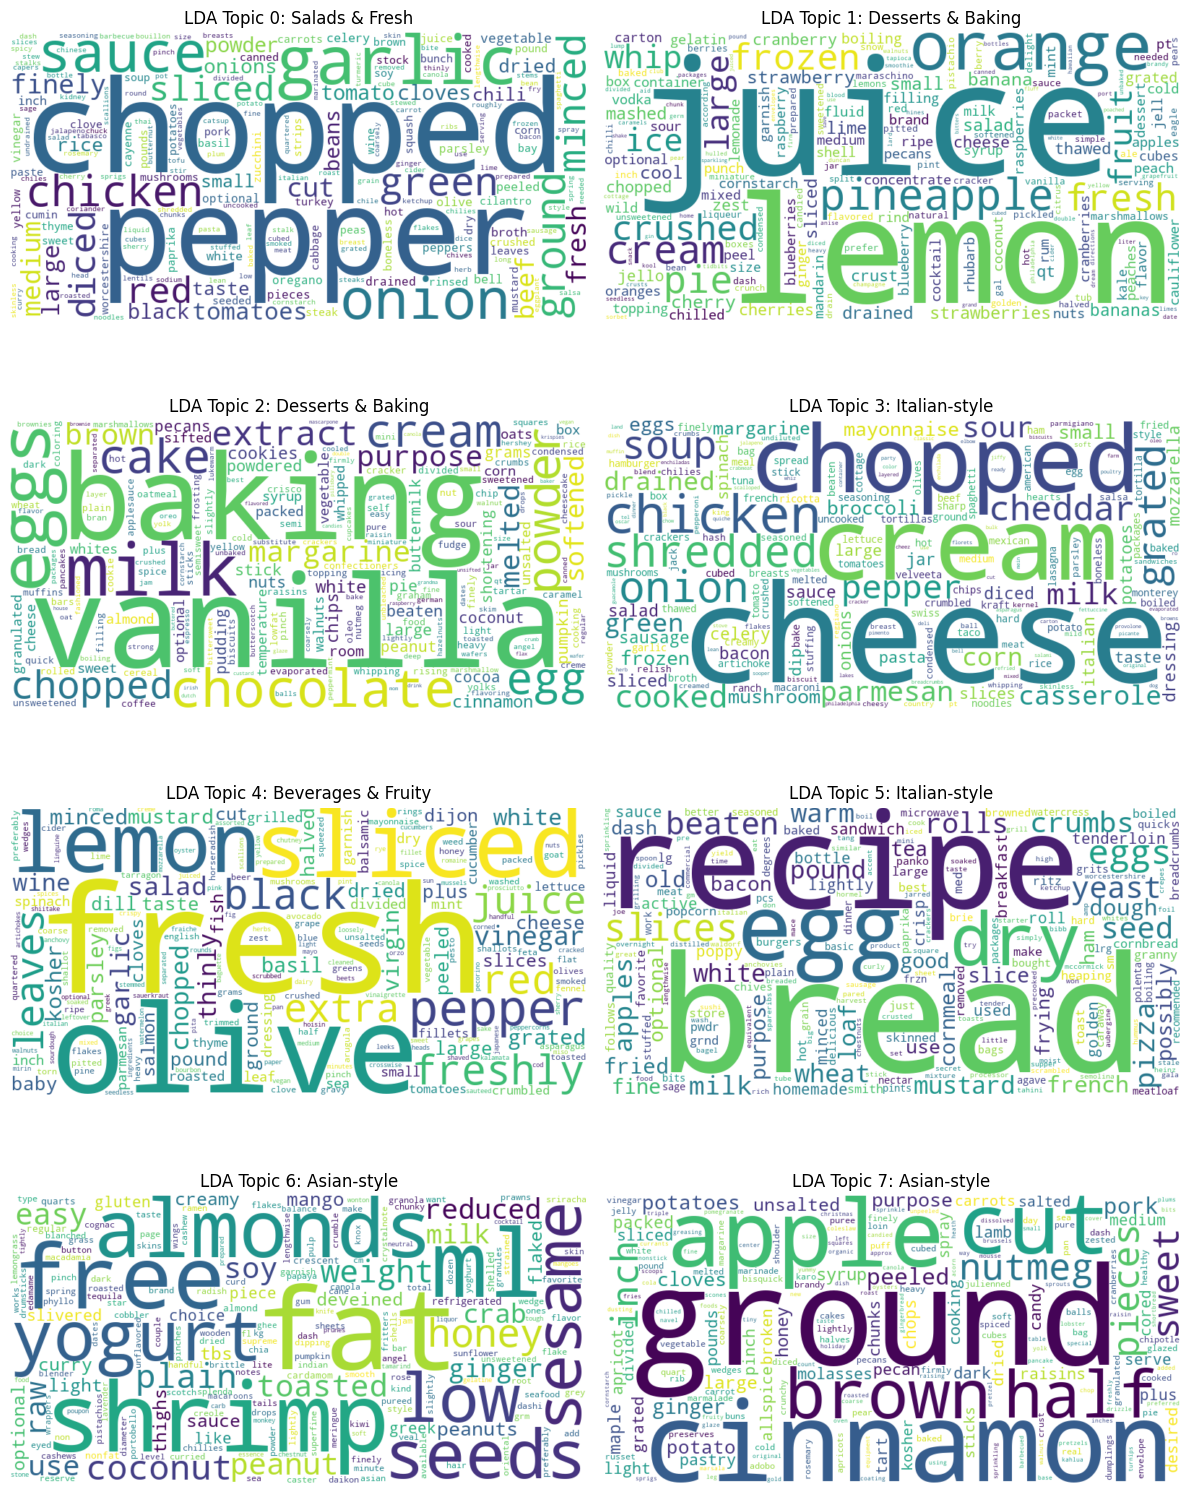

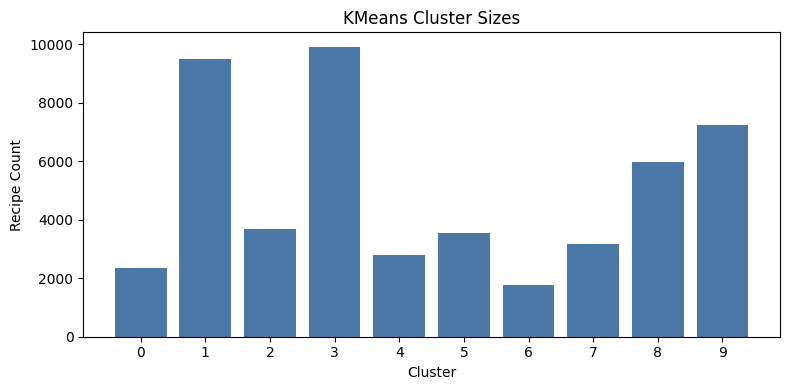

Computing silhouette plot...


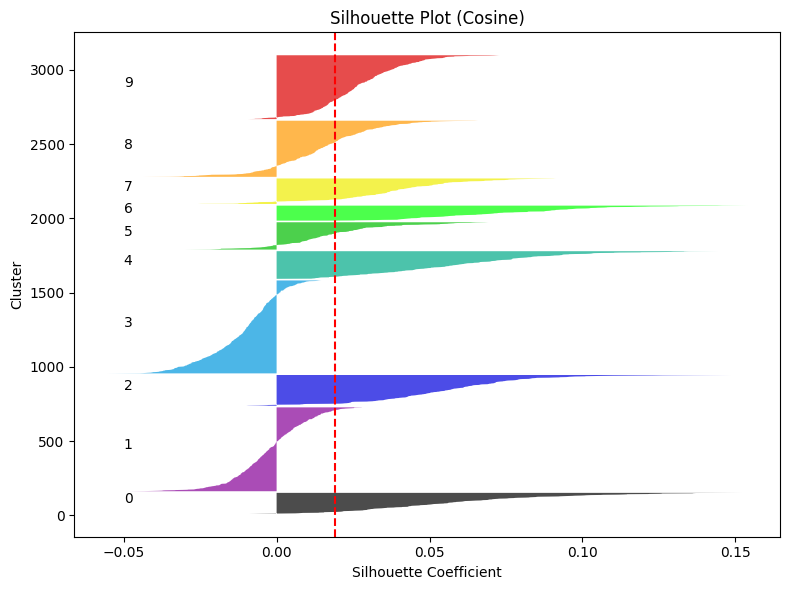

In [41]:
# Visualizations: LDA word clouds, cluster sizes, silhouette plot [OPTIMIZED]

# LDA topic word clouds
num_topics = lda_model.n_components
cols = 2
rows = int(np.ceil(num_topics / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).reshape(-1)

vocab = np.array(count_vectorizer.get_feature_names_out())

for topic_idx in range(len(axes)):
    ax = axes[topic_idx]
    if topic_idx >= num_topics:
        ax.axis("off")
        continue

    weights = lda_model.components_[topic_idx]
    freqs = {vocab[i]: weights[i] for i in range(len(vocab))}
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"LDA Topic {topic_idx}: {lda_labels[topic_idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# KMeans cluster size bar plot
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color="#4C78A8")
plt.title("KMeans Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Recipe Count")
plt.tight_layout()
plt.show()

# Silhouette plot (optimized with sampling)
print("Computing silhouette plot...")
max_silhouette_points = 3000  # Reduced from 10000 to avoid memory errors
if len(df_spec) > max_silhouette_points:
    rng = np.random.RandomState(RANDOM_STATE)
    sil_idx = rng.choice(len(df_spec), size=max_silhouette_points, replace=False)
    X_sil = X_tfidf[sil_idx]
    labels_sil = kmeans_labels[sil_idx]
else:
    X_sil = X_tfidf
    labels_sil = kmeans_labels

sil_vals = silhouette_samples(X_sil, labels_sil, metric="cosine")

plt.figure(figsize=(8, 6))
y_lower = 10
for k in range(best_k):
    kth_vals = sil_vals[labels_sil == k]
    kth_vals.sort()
    size_k = kth_vals.shape[0]
    y_upper = y_lower + size_k
    color = plt.cm.nipy_spectral(float(k) / best_k)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, kth_vals, facecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_k, str(k))
    y_lower = y_upper + 10

plt.axvline(x=sil_vals.mean(), color="red", linestyle="--")
plt.title("Silhouette Plot (Cosine)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [42]:
# STEP 3: Compare both methods

print("="*60)
print("FINAL RESULTS: Cuisine Discovery")
print("="*60)

print(f"\nDataset: {len(df):,} recipes total")
print(f"LDA trained on: {len(df):,} recipes")
print(f"KMeans clustering on: {len(df_spec):,} recipes")

print("\nLDA cuisine count:", df["Cuisine_LDA"].nunique())
print("KMeans cuisine count:", df_spec["Cuisine_KMeans"].nunique())

print("\n" + "="*60)
print("LDA Cuisine Distribution")
print("="*60)
print(df["Cuisine_LDA"].value_counts())

print("\n" + "="*60)
print("KMeans Cuisine Distribution")
print("="*60)
print(df_spec["Cuisine_KMeans"].value_counts())

# Overlap between LDA and KMeans (on the subset used for kmeans)
if len(df_spec) == len(df):
    overlap = pd.crosstab(df["Cuisine_LDA"], df_spec["Cuisine_KMeans"])
else:
    # Compare only on the kmeans subset
    df_subset_lda = df.loc[df.index.isin(df_spec.index), "Cuisine_LDA"]
    overlap = pd.crosstab(df_subset_lda, df_spec["Cuisine_KMeans"])

print("\n" + "="*60)
print("Overlap (LDA vs KMeans)")
print("="*60)
print(overlap)

print("\n" + "="*60)
print("SUMMARY: Discovered Cuisine Patterns")
print("="*60)
print(f"Optimal LDA topics: {optimal_k}")
print(f"Optimal KMeans clusters: {best_k}")

print("\n--- LDA Topics ---")
for idx, words in enumerate(lda_topic_words):
    print(f"\n{lda_labels[idx]} (Topic {idx}):")
    print(f"  Keywords: {', '.join(words[:8])}")

print("\n--- KMeans Clusters ---")
for cid, words in cluster_top_words.items():
    label = kmeans_labels_text[cid]
    print(f"\n{label} (Cluster {cid}):")
    print(f"  Keywords: {', '.join(words[:8])}")
    print(f"  Size: {(kmeans_labels == cid).sum()} recipes")

FINAL RESULTS: Cuisine Discovery

Dataset: 50,000 recipes total
LDA trained on: 50,000 recipes
KMeans clustering on: 50,000 recipes

LDA cuisine count: 5
KMeans cuisine count: 10

LDA Cuisine Distribution
Cuisine_LDA
Desserts & Baking     17535
Salads & Fresh        15778
Italian-style          9722
Beverages & Fruity     4600
Asian-style            2365
Name: count, dtype: int64

KMeans Cuisine Distribution
Cuisine_KMeans
Cluster 3    9917
Cluster 1    9508
Cluster 9    7243
Cluster 8    5967
Cluster 2    3688
Cluster 5    3557
Cluster 7    3182
Cluster 4    2796
Cluster 0    2366
Cluster 6    1776
Name: count, dtype: int64

Overlap (LDA vs KMeans)
Cuisine_KMeans      Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  \
Cuisine_LDA                                                                 
Asian-style               108        447        183        465        111   
Beverages & Fruity        207        872        347        944        258   
Desserts & Baking         844     

In [43]:
# Save models and vectorizers

import joblib

# Save LDA model and its vectorizer
joblib.dump(lda_model, "lda_model.pkl")
joblib.dump(count_vectorizer, "count_vectorizer.pkl")
joblib.dump(lda_labels, "lda_labels.pkl")

print("✓ Saved: lda_model.pkl")
print("✓ Saved: count_vectorizer.pkl")
print("✓ Saved: lda_labels.pkl")

# Save KMeans Clustering model components
joblib.dump(kmeans_model, "kmeans_model.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(kmeans_labels_text, "kmeans_labels_text.pkl")

print("✓ Saved: kmeans_model.pkl")
print("✓ Saved: tfidf_vectorizer.pkl")
print("✓ Saved: kmeans_labels_text.pkl")

# Save additional useful objects
joblib.dump(cluster_top_words, "cluster_top_words.pkl")
joblib.dump(optimal_k, "optimal_lda_k.pkl")
joblib.dump(best_k, "optimal_kmeans_k.pkl")

print("✓ Saved: cluster_top_words.pkl")
print("✓ Saved: optimal_lda_k.pkl")
print("✓ Saved: optimal_kmeans_k.pkl")

print("\n" + "="*60)
print("All models saved successfully!")
print("="*60)

✓ Saved: lda_model.pkl
✓ Saved: count_vectorizer.pkl
✓ Saved: lda_labels.pkl
✓ Saved: kmeans_model.pkl
✓ Saved: tfidf_vectorizer.pkl
✓ Saved: kmeans_labels_text.pkl
✓ Saved: cluster_top_words.pkl
✓ Saved: optimal_lda_k.pkl
✓ Saved: optimal_kmeans_k.pkl

All models saved successfully!
